<a href="https://colab.research.google.com/github/mohammedaslanshas/codomax-ds-internship/blob/main/netflix-mini-project/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()   # pick the downloaded CSV file

import pandas as pd
df = pd.read_csv("netflix_titles.csv")   # match the exact filename you uploaded

Saving netflix_titles.csv to netflix_titles (1).csv


In [2]:
print(df.shape)
df.head()
df.info()
print(df.isnull().sum())
df.describe(include="all")

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
descriptio

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [3]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

# Small enough to just drop these few rows
df = df.dropna(subset=["date_added", "rating", "duration"])

# Verify
print(df.isnull().sum())
print(df.shape)

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64
(8790, 12)


In [4]:
# date_added is currently text — convert to actual datetime
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())

print(df["date_added"].dtype)
print(df["date_added"].head())

datetime64[ns]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]


In [5]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

print(df[["date_added", "year_added", "month_added"]].head())

  date_added  year_added  month_added
0 2021-09-25        2021            9
1 2021-09-24        2021            9
2 2021-09-24        2021            9
3 2021-09-24        2021            9
4 2021-09-24        2021            9


In [6]:
print(df["duration"].unique()[:10])

['90 min' '2 Seasons' '1 Season' '91 min' '125 min' '9 Seasons' '104 min'
 '127 min' '4 Seasons' '67 min']


In [7]:
import numpy as np
# Extract just the number
df["duration_number"] = df["duration"].str.extract("(\d+)").astype(float)

# Keep track of the unit separately
df["duration_unit"] = np.where(df["type"] == "Movie", "minutes", "seasons")

print(df[["type", "duration", "duration_number", "duration_unit"]].head())

      type   duration  duration_number duration_unit
0    Movie     90 min             90.0       minutes
1  TV Show  2 Seasons              2.0       seasons
2  TV Show   1 Season              1.0       seasons
3  TV Show   1 Season              1.0       seasons
4  TV Show  2 Seasons              2.0       seasons


<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_36978/3862051074.py:3: SyntaxWarning: invalid escape sequence '\d'
  df["duration_number"] = df["duration"].str.extract("(\d+)").astype(float)


In [8]:
print(df["listed_in"].head())

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object


In [9]:
print(df.isnull().sum())
print(df.shape)
df.info()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
year_added         0
month_added        0
duration_number    0
duration_unit      0
dtype: int64
(8790, 16)
<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8790 non-null   object        
 1   type             8790 non-null   object        
 2   title            8790 non-null   object        
 3   director         8790 non-null   object        
 4   cast             8790 non-null   object        
 5   country          8790 non-null   object        
 6   date_added       8790 non-null   datetime64[ns]
 7   release_year     8790 non-null   int64         
 8   rat

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      NaN
2010           1.0      NaN
2011          13.0      NaN
2012           3.0      NaN
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         251.0    175.0
2017         836.0    349.0
2018        1237.0    411.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


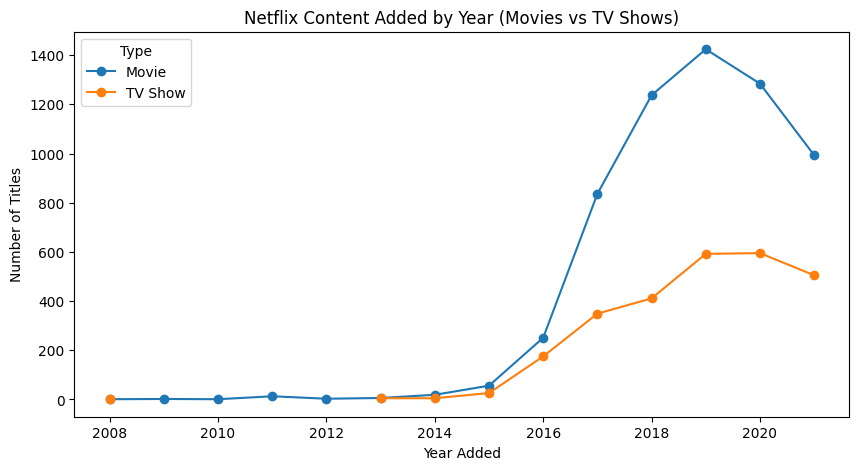

In [11]:
content_by_year = df.groupby(["year_added", "type"]).size().unstack()
print(content_by_year)

content_by_year.plot(kind="line", figsize=(10,5), marker="o")
plt.title("Netflix Content Added by Year (Movies vs TV Shows)")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.show()

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


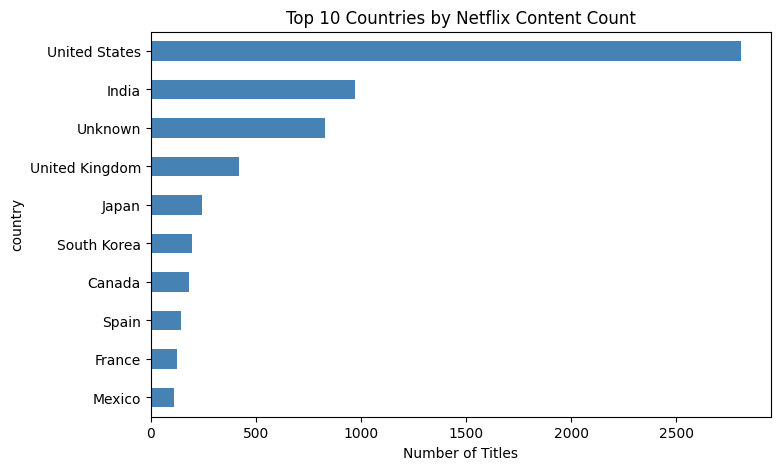

In [12]:
top_countries = df["country"].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(8,5))
top_countries.plot(kind="barh", color="steelblue")
plt.title("Top 10 Countries by Netflix Content Count")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()   # largest bar on top
plt.show()

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


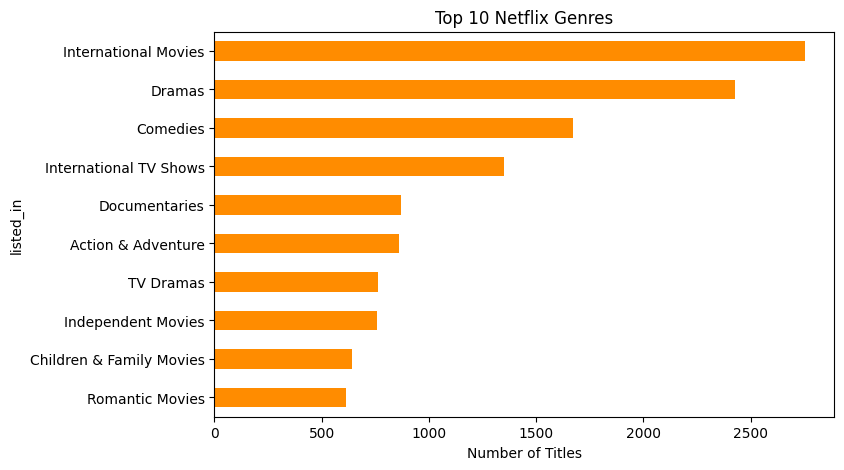

In [13]:
# Split the comma-separated genres into a list, then explode so each genre gets its own row
genres = df["listed_in"].str.split(", ").explode()

top_genres = genres.value_counts().head(10)
print(top_genres)

plt.figure(figsize=(8,5))
top_genres.plot(kind="barh", color="darkorange")
plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.show()

In [14]:
# Returns array of distinct values
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

type      Movie  TV Show
rating                  
G            41        0
NC-17         3        0
NR           75        4
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      730
TV-G        126       94
TV-MA      2062     1143
TV-PG       540      321
TV-Y        131      175
TV-Y7       139      194
TV-Y7-FV      5        1
UR            3        0


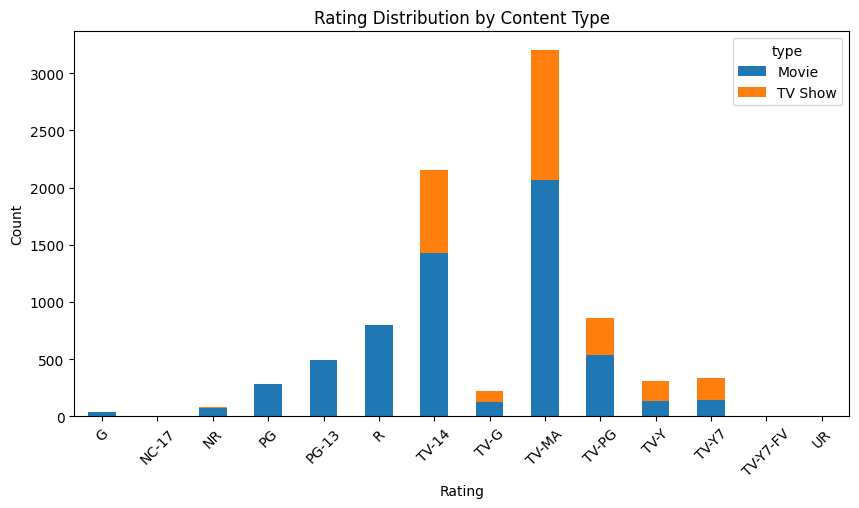

In [15]:
rating_by_type = pd.crosstab(df["rating"], df["type"])
print(rating_by_type)

rating_by_type.plot(kind="bar", figsize=(10,5), stacked=True)
plt.title("Rating Distribution by Content Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

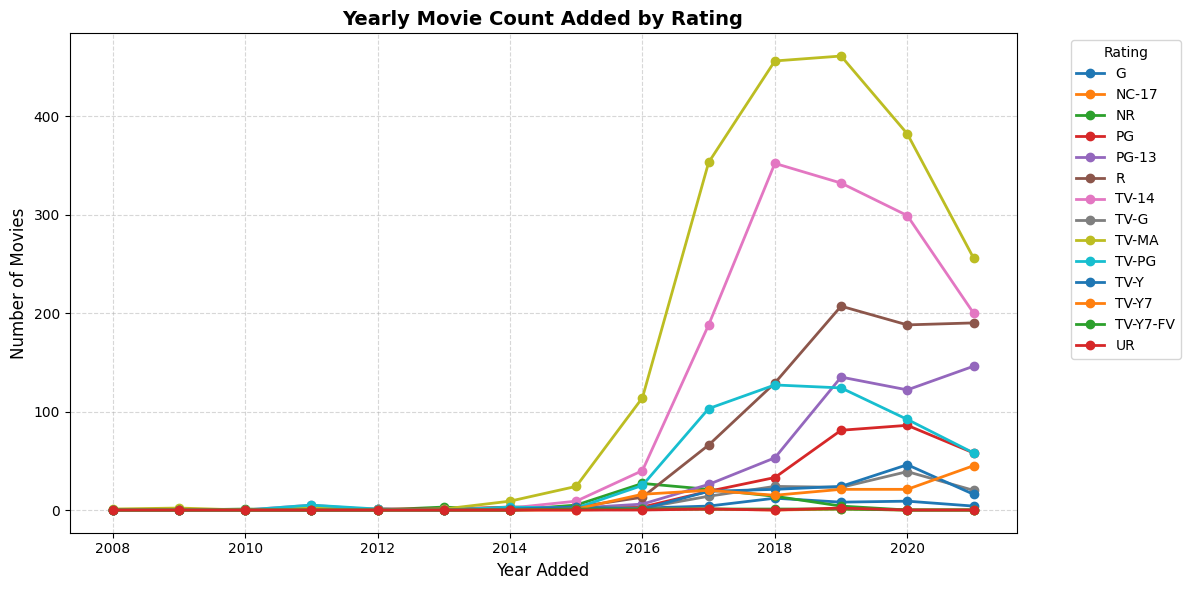

In [16]:
import matplotlib.pyplot as plt

# 1. Filter dataset for 'Movie' type only
movies_df = df[df["type"] == "Movie"]

# 2. Group by year_added and rating (MultiIndex -> unstack)
movie_yearly = (
    movies_df.groupby(["year_added", "rating"]).size().unstack(fill_value=0)
)

# 3. Plot line graph
plt.figure(figsize=(12, 6))
movie_yearly.plot(kind="line", marker="o", ax=plt.gca(), linewidth=2)

plt.title(
    "Yearly Movie Count Added by Rating", fontsize=14, fontweight="bold"
)
plt.xlabel("Year Added", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

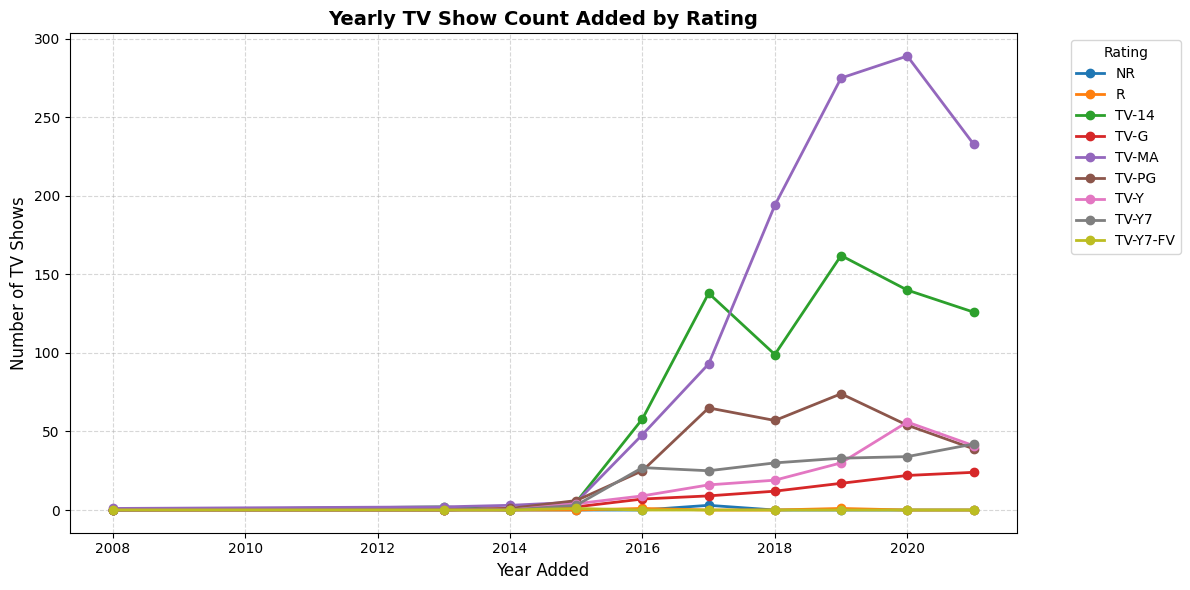

In [19]:
import matplotlib.pyplot as plt

# 1. Filter dataset for 'TV Show' type (without leading space)
tv_df = df[df["type"] == "TV Show"]

# 2. Group by year_added and rating
tv_yearly = tv_df.groupby(["year_added", "rating"]).size().unstack(fill_value=0)

# 3. Plot line graph
plt.figure(figsize=(12, 6))
tv_yearly.plot(kind="line", marker="o", ax=plt.gca(), linewidth=2)

plt.title(
    "Yearly TV Show Count Added by Rating", fontsize=14, fontweight="bold"
)
plt.xlabel("Year Added", fontsize=12)
plt.ylabel("Number of TV Shows", fontsize=12)
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

In [18]:
content_by_year_pct = content_by_year.div(content_by_year.sum(axis=1), axis=0) * 100
print(content_by_year_pct)

type             Movie    TV Show
year_added                       
2008         50.000000  50.000000
2009        100.000000        NaN
2010        100.000000        NaN
2011        100.000000        NaN
2012        100.000000        NaN
2013         54.545455  45.454545
2014         79.166667  20.833333
2015         68.292683  31.707317
2016         58.920188  41.079812
2017         70.548523  29.451477
2018         75.060680  24.939320
2019         70.634921  29.365079
2020         68.334220  31.665780
2021         66.288385  33.711615
